# Problem Statement: Build a Smart Mutual Fund Advisor

*On top of the Mutual Funds Report, [sourced](https://www.kaggle.com/datasets/dhavalrupapara/mutual-funds-market-dataset) from Kaggle*

---

## Objective  
Create a Gradio-based AI assistant that recommends a mutual fund investment portfolio based on the user's risk and return preferences. The app uses Retrieval-Augmented Generation (RAG) on a structured Mutual Fund product dataset, generating explainable, structured results.

---

## User App (Essential Features)

### Inputs
- **Investment Needs**: Free-form text input  
  *(e.g., “high return portfolio, only from Aditya Birla fund house”)*
  
### Output
- **Suggestion**: A natural language explanation of what's recommended and why
- **Recommended Mutual Funds**: Structured as a list containing:
  - Scheme Name
  - Fund House
---

## Developer-Facing Advanced Settings

Shown under a collapsible **LLM Settings (Advanced)** section in the UI.

### Model & Generation Settings
- **Model Selector**: *select 2 more open-source / closed-source models*
  - GPT OSS 120B (`gpt-oss-120b`)
- **Temperature Slider**: Adjustable between 0 and 2

These settings allow developers to tune how deterministic or creative the model’s responses are.

---

## Backend Setup

### Vector Store and RAG
- **Embedding Model**: Nomic Embed Text via Ollama, or other model of your choice
- **Vector Database**: ChromaDB, or other vector DB of your choice
- **RAG Workflow**:
  1. Load product catalog using `CSVLoader`
  2. Parse and clean fields into `Document` objects with metadata
  3. Generate embeddings and index documents
  4. Perform similarity search based on user preferences
  5. Use an LLM to generate structured output parsed via `PydanticOutputParser`

# Part 1: Implement the Solution

## Setup

In [1]:
import gradio as gr
import pandas as pd
import os
import warnings
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.output_parsers import PydanticOutputParser
from langchain.schema.output_parser import OutputParserException
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from uuid import uuid4
from langgraph.graph import START, StateGraph, END
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver

In [2]:
warnings.filterwarnings('ignore')
load_dotenv(override=True)

True

In [3]:
#Check for Groq API Key
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ API Key: ")
    groq_ch = input("Huggingface token not found: Do you want to enter it manually here? (y/n): ")
    if groq_ch.lower() == 'y':
        os.environ["HF_TOKEN"] = getpass.getpass("Hugging Face API Key: ")
    else:
        print("You can add it in .env file in the project directory...")
else:
    print("Groq key found, and is being used...")

Groq key found, and is being used...


In [4]:
#Set Hugging Face token (as we will be using some of Hugging Face's functionalities
from huggingface_hub.hf_api import HfFolder
if os.environ['HF_TOKEN']:
  HfFolder.save_token(os.environ["HF_TOKEN"])
  print("Hugging Face token found, and is being used...")

else:
  ch = input("Huggingface token not found: Do you want to enter it manually here? (y/n): ")
  if ch.lower() == 'y':
    os.environ["HF_TOKEN"] = getpass.getpass("Hugging Face API Key: ")
  else:
    print("You can add it in .env file in the project directory...")

Hugging Face token found, and is being used...


## Defining Components

### Chat Model

In [5]:
# TODO: Model name map for UI Mapping
model_name_map = {
    "GPT-OSS-120B": "openai/gpt-oss-120b",
    "GPT-OSS-20B": "openai/gpt-oss-20b",
    "Qwen-3.8-27B": "qwen/qwen3.8-27b"
}

model_choices = [
    "GPT-OSS-120B (Groq)",
    "GPT-OSS-20B (Groq)",
    "Qwen-3.8-27B (Groq)"
]

In [6]:
## TODO: Model Selector
def get_llm(model_choice, temperature):
    if "Groq" in model_choice:
        return init_chat_model(model_name_map[model_choice.split(" ")[0]], model_provider="groq", temperature = temperature)
    else:
        raise ValueError("Invalid model")

### Embedding Model

In [7]:
## TODO: Create embeddings
## Use: OllamaEmbeddings with llama3.2:1b and pull the model beforehand

%pip install -q sentence-transformers langchain-huggingface

Note: you may need to restart the kernel to use updated packages.


c:\Dhiren\Jio Institute\Course\Term 4\Gen AI\Codes\GenAI\.venv\Scripts\python.exe: No module named pip


In [8]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

### Vector Store

In [9]:
## TODO: Initialize ChromaDB with a persist directory set
from langchain_chroma import Chroma

vectorstore = Chroma(
    collection_name="mutual_funds",
    embedding_function=embeddings_model,
    persist_directory="./chroma_db"
)

## Load and Preprocess Data

In [10]:
# Load and preprocess data
loader = CSVLoader(file_path="mutual_funds_data.csv", source_column="scheme_code")
documents_raw = loader.load()

In [11]:
# Convert page_content string to dict and build metadata
documents = []

for doc in documents_raw:
    try:
        row_data = dict(
            line.split(":", 1)
            for line in doc.page_content.split("\n")
            if ":" in line
        )
        row_data = {k.strip(): v.strip() for k, v in row_data.items()}

        ## TODO: Keep Scheme Name, Fund House, Scheme Type, Scheme Category, Net Asset Value and Date in content
        page_text = (
            f"Scheme Name: {row_data.get('scheme_name', '')}\n"
            f"Fund House: {row_data.get('fund_house', '')}\n"
            f"Scheme Type: {row_data.get('scheme_type', '')}\n"
            f"Scheme Category: {row_data.get('scheme_category', '')}\n"
            f"Net Asset Value: {row_data.get('net_asset_value', '')}\n"
            f"Date: {row_data.get('date', '')}"
        )

        ## TODO: Keep Scheme Type, Scheme Category in metadata
        metadata = {
            "scheme_type": row_data.get("scheme_type", ""),
            "scheme_category": row_data.get("scheme_category", "")
        }

        documents.append(
            Document(
                page_content=page_text,
                metadata=metadata
            )
        )

    except Exception as e:
        print("Skipping row due to error:", e)

In [12]:
len(documents)

35559

In [13]:
print(documents[0].page_content)

Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend
Fund House: Standard Chartered Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Income
Net Asset Value: 10.7205
Date: 29-05-2008


In [14]:
len(documents)

35559

## Store in Vector DB

In [15]:
## Store in Chroma - 1000 rows only for quicker processing - and make sure to add UUIDs
## TODO: Add UUIDs
uuids = [str(uuid4()) for _ in documents[:1000]]

## TODO: Add documents
documents_to_store = documents[:1000]

vectorstore.add_documents(
    documents=documents_to_store,
    ids=uuids
)


['fda2fa42-ec50-47a6-967a-c4905ebe3551',
 'b79a5369-82b8-4c4e-97b4-c9a11dafd6f5',
 '46af90eb-2113-4d17-bb80-1e4b2a7c87f7',
 '4970619f-35ee-4cd6-813c-6730a24857ae',
 '7cdf6542-76c5-4fcb-82bc-2d861eb4d835',
 '79cc9674-2488-4460-9c98-5a7258ad6435',
 '6a18a802-def2-4fa1-8fbd-6ac0ecaecaca',
 'ef8ba486-7076-4ebe-a659-60a06e52a0ae',
 'a0195b29-a36e-4b4e-a323-bd6bdf0616a3',
 '476eead7-ef64-4c56-83f0-41a88ac2e7df',
 '68ef1cee-9d4e-477a-97a4-35efec4b035b',
 'e96f4f0d-7986-46f2-a951-94ebeeecfbe6',
 '67ce338d-395e-4f53-8c0e-db153bc6a2bb',
 '917c21ef-d5b3-476b-a465-58bb20143e05',
 'e6a83ada-e9e9-49db-a81a-5f3befffa192',
 '77efdf46-cb41-4097-951a-59f2bd40a126',
 '1bd23b5b-9e1f-4fba-a074-8837e9b5d64d',
 '772f6cd8-dd1d-4a66-8a01-eedc61ef2bf3',
 '2d7d711b-004a-4db7-b7c4-511cda8bf830',
 'aea4f0eb-f1c2-4925-a00d-971ad8d86a7a',
 'bc599b51-9440-424d-8ce0-a228c570178d',
 'a26c22c2-5872-4cb9-a1b0-d54d2f7d3192',
 '87a2153b-5422-4742-9463-81f74ab9967a',
 '033ae46b-ff60-431c-84f2-3ca0bbe020ec',
 'be84721f-475b-

## Initializing for RAG

### Initialize Retriever

In [16]:
## TODO: Initializer Retriever below
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)


### Define Pydantic Schema

In [17]:
class MutualFund(BaseModel):
    scheme_name: str = Field(description="Name of the mutual fund scheme")
    fund_house: str = Field(description="Fund house managing the mutual fund")
    scheme_type: str = Field(description="Type of the mutual fund scheme")
    scheme_category: str = Field(description="Category of the mutual fund scheme")


class MutualFundOutput(BaseModel):
    reasoning: str = Field(description="Explanation for the recommended mutual funds")
    schemes: List[MutualFund] = Field(description="List of recommended mutual funds")


parser = PydanticOutputParser(pydantic_object=MutualFundOutput)

### Define Prompt

In [18]:
template = ChatPromptTemplate.from_template("""
You are a mutual fund advisor. Based on the user's preferences and the retrieved mutual fund data, recommend relevant mutual funds.

User preferences:
{preferences}

Retrieved mutual funds:
{context}

Rules:
- Recommend mutual funds only from the retrieved context.
- Do not recommend two mutual funds from the same fund house and scheme type.
- Provide a clear reasoning for the recommendations.
- Return the output in the required format.

{format_instructions}
""")

## Creating RAG Pipeline

### Test RAG Pipeline Manually

In [19]:
preferences = "I want a low risk investment portfolio."

context_docs = retriever.invoke(preferences)

relevant_text = "\n\n".join(
    doc.page_content for doc in context_docs
)

llm = get_llm("GPT-OSS-120B (Groq)", 0.2)

chain = template | llm | parser

input_dict = {
    "preferences": preferences,
    "context": relevant_text,
    "format_instructions": parser.get_format_instructions()
}

chain.invoke(input_dict)

MutualFundOutput(reasoning='For a low‑risk investment profile, debt‑oriented funds with short‑term horizons are appropriate because they exhibit lower volatility and preserve capital. The LIC MF Low Duration Fund (a low‑duration debt scheme) invests in high‑quality short‑term instruments, offering stable returns with minimal interest‑rate risk. The Templeton Floating Rate Income Fund (a short‑term income scheme) holds floating‑rate securities that adjust with market rates, further limiting interest‑rate exposure. Both funds are open‑ended, managed by different fund houses, and align well with a conservative risk tolerance.', schemes=[MutualFund(scheme_name='LIC MF Low Duration Fund-Regular Plan-Growth', fund_house='LIC Mutual Fund', scheme_type='Open Ended Schemes', scheme_category='Debt Scheme - Low Duration Fund'), MutualFund(scheme_name='Templeton Floating Rate Income Fund-Short Term Plan-Institutional Option - Growth', fund_house='Franklin Templeton Mutual Fund', scheme_type='Open 

### Define RAG Pipeline Function

In [20]:
# RAG pipeline
def generate_portfolio(model_choice, user_input):
    context_docs = retriever.invoke(user_input)

    relevant_funds = "\n\n".join(
        doc.page_content for doc in context_docs
    )

    llm = get_llm(model_choice, 0.2)

    # Invoking
    chain = template | llm

    output = chain.invoke({
        "preferences": user_input,
        "context": relevant_funds,
        "format_instructions": parser.get_format_instructions()
    })

    # Exception Handling
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None

    return result

## User Interface

In [21]:
def gradio_interface(preferences, model_choice, temperature):
    try:
        result = generate_portfolio(model_choice, preferences)

        if not result or isinstance(result, str):
            return result or "Could not generate portfolio.", ""

        list_output = "\n".join(
            f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
            for scheme in result.schemes
        )

        return result.reasoning, list_output

    except Exception as e:
        return f"Error: {str(e)}", ""

In [22]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [23]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


# Part 2: Implement the RAG pipeline in LangGraph

## Creating Graph

### Define State Class

In [24]:
class State(TypedDict):
    preferences: str
    context: list
    answer: object

### Define Nodes

In [25]:
## TODO: Define retrieve node
def retrieve(state):
    relevant_funds = retriever.invoke(state["preferences"])
    return {"context": relevant_funds}

In [26]:
## TODO: Define generate node
def generate(state):
    relevant_funds_str = "\n\n".join(
        doc.page_content for doc in state["context"]
    )

    chain = template | llm_graph

    output = chain.invoke({
        "preferences": state["preferences"],
        "context": relevant_funds_str,
        "format_instructions": parser.get_format_instructions()
    })

    # Exception Handling for Output Parser
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return {"answer": "Could not parse output."}

    return {"answer": result}

### Build and Compile Graph

In [27]:
## TODO: Build the graph with 2 nodes and 3 edges
graph_builder = StateGraph(State)

graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [28]:
#Compile graph
graph = graph_builder.compile()

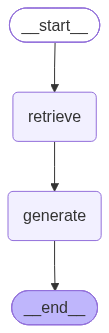

In [29]:
#Visualize graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Test Manually

In [30]:
preferences = "I want a low risk investment portfolio."

llm_graph = get_llm("GPT-OSS-120B (Groq)", 0.2)

result = graph.invoke({"preferences": preferences})

print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(id='e51b1582-1b5a-4509-ba3e-0b46671f79c2', metadata={'scheme_category': 'Debt Scheme - Low Duration Fund', 'scheme_type': 'Open Ended Schemes'}, page_content='Scheme Name: LIC MF Low Duration Fund-Regular Plan-Growth\nFund House: LIC Mutual Fund\nScheme Type: Open Ended Schemes\nScheme Category: Debt Scheme - Low Duration Fund\nNet Asset Value: 35.1561\nDate: 27-10-2023'), Document(id='1032efae-2b85-4863-bf04-14586cb952f1', metadata={'scheme_category': 'Debt Scheme - Low Duration Fund', 'scheme_type': 'Open Ended Schemes'}, page_content='Scheme Name: LIC MF Low Duration Fund-Regular Plan-Growth\nFund House: LIC Mutual Fund\nScheme Type: Open Ended Schemes\nScheme Category: Debt Scheme - Low Duration Fund\nNet Asset Value: 35.1561\nDate: 27-10-2023'), Document(id='4522c2ce-c414-43ca-9a5c-48f873fd5689', metadata={'scheme_type': 'Open Ended Schemes', 'scheme_category': 'Income'}, page_content='Scheme Name: Templeton Floating Rate Income Fund-Short Term Plan-Institutiona

## User Interface

In [31]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    llm_graph = get_llm(user_input["model_choice"], user_input["temperature"])
    result = graph.invoke({"preferences": preferences})["answer"]
    
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [32]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [33]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
